# 01 - Data Inspection

## Objetivo
Explorar el archivo EEG crudo para:
- Verificar estructura de canales
- Identificar tipos de canal
- Detectar eventos experimentales
- Evaluar calidad de señal inicial

## Dataset
Archivo: subject-47-eeg_2023-03-30.bdf
Formato: BDF (BioSemi Data Format)
Duración aproximada: ~36 minutos
Frecuencia de muestreo: 500 Hz

Este notebook corresponde a la fase exploratoria del proyecto.

In [5]:
import mne

raw = mne.io.read_raw_bdf(
    "../data/raw/eeg/subject-47-eeg_2023-03-30.bdf",
    preload=False
)

raw

Extracting BDF parameters from ../data/raw/eeg/subject-47-eeg_2023-03-30.bdf...
Setting channel info structure...
Creating raw.info structure...


<RawBDF | subject-47-eeg_2023-03-30.bdf, 26 x 1090500 (2181.0 s), ~24 KiB, data not loaded>

## Inspección de nombres de canales

Se listan los nombres de los canales registrados en el archivo EEG.
Esto permite verificar la disposición según el sistema 10–20 y detectar canales auxiliares.

In [6]:
raw.ch_names

['F7',
 'Fp1',
 'Fp2',
 'F8',
 'F3',
 'Fz',
 'F4',
 'C3',
 'Cz',
 'P8',
 'P7',
 'Pz',
 'P4',
 'T3',
 'P3',
 'O1',
 'O2',
 'C4',
 'T4',
 'A2',
 'ExG 1',
 'ACC21',
 'ACC22',
 'ACC23',
 'Packet Counter',
 'TRIGGER']

## Tipos de canal

Se revisa cómo MNE clasifica cada canal.
Es importante verificar si canales auxiliares están mal etiquetados.

In [7]:
raw.get_channel_types()

['eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'stim']

El archivo EEG contiene canales EEG distribuidos según el sistema internacional 10–20, además de canales auxiliares (ExG y acelerómetros) y un canal de estímulo (TRIGGER) utilizado para marcar eventos experimentales.

MNE reconoce correctamente los canales EEG y detecta el canal TRIGGER como canal de estímulo (stim). Los canales auxiliares y técnicos se encuentran inicialmente clasificados como EEG, lo cual será ajustado durante la etapa de preprocesamiento.

Using matplotlib as 2D backend.


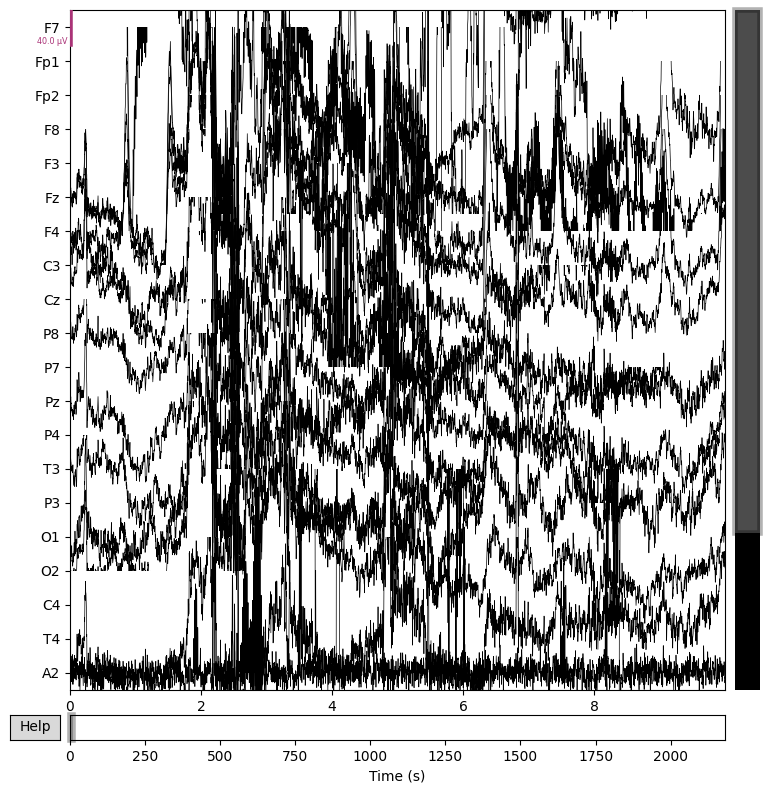

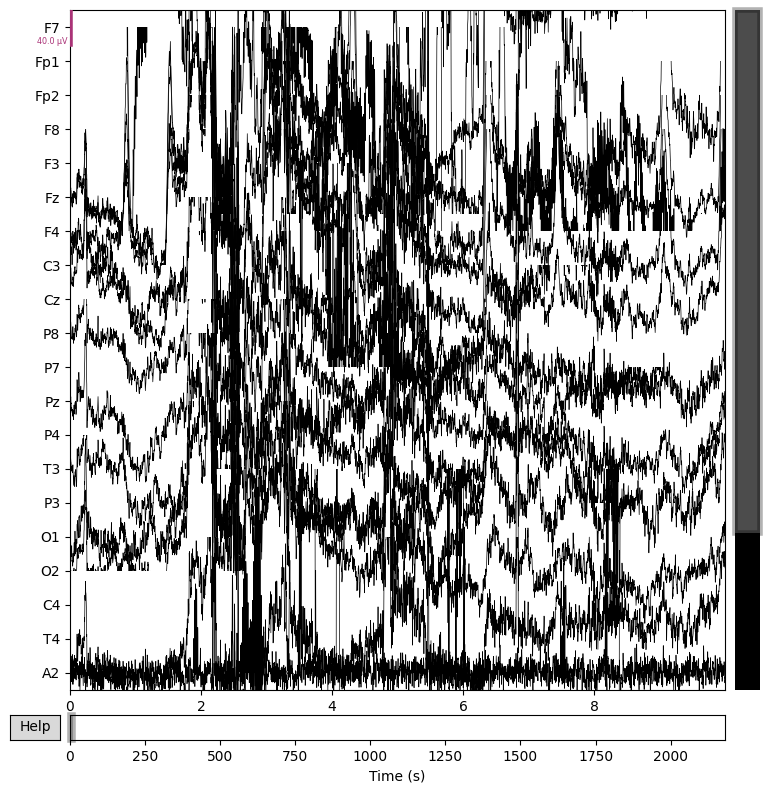

In [8]:
raw.plot()

La inspección visual de la señal EEG cruda muestra presencia de artefactos oculares en canales frontales, ruido de alta frecuencia y drift lento, características típicas de registros EEG sin procesar.

In [6]:
import mne

raw = mne.io.read_raw_bdf(
    "../data/raw/eeg/subject-47-eeg_2023-03-30.bdf",
    preload=False
)

raw

Extracting BDF parameters from ../data/raw/eeg/subject-47-eeg_2023-03-30.bdf...
Setting channel info structure...
Creating raw.info structure...


<RawBDF | subject-47-eeg_2023-03-30.bdf, 26 x 1090500 (2181.0 s), ~24 KiB, data not loaded>

## Detección de eventos experimentales

Se extraen los eventos almacenados en el canal TRIGGER.
Estos eventos representan estímulos o condiciones del experimento.

In [7]:
events = mne.find_events(raw)
events[:10]

Finding events on: TRIGGER
498 events found on stim channel TRIGGER
Event IDs: [    1     2     3     4     5     6     7     8     9    10    11    12
    13    14    15    16    17    18    19    20    21    22    23    24
    25    26    27    28    29    30    31    32    33    34 65535]


array([[43712,     0,    34],
       [44721,     0, 65535],
       [46213,     0, 65535],
       [47721,     0, 65535],
       [49221,     0, 65535],
       [50721,     0, 65535],
       [55803,     0,    34],
       [56812,     0, 65535],
       [58313,     0, 65535],
       [59821,     0, 65535]])

In [10]:
import pandas as pd

event_counts = pd.Series(events[:, 2]).value_counts().sort_index()
event_counts

1          2
2          3
3          3
4          2
5          3
6          2
7          2
8          3
9          2
10         3
11         2
12         2
13         3
14         3
15         2
16         3
17         2
18         3
19         3
20         2
21         3
22         2
23         2
24         3
25         2
26         3
27         2
28         2
29         3
30         3
31         2
32         3
33         6
34         2
65535    410
Name: count, dtype: int64

In [11]:
clean_events = events[events[:, 2] != 65535]

len(clean_events)

88

In [12]:
pd.Series(clean_events[:, 2]).value_counts().sort_index()

1     2
2     3
3     3
4     2
5     3
6     2
7     2
8     3
9     2
10    3
11    2
12    2
13    3
14    3
15    2
16    3
17    2
18    3
19    3
20    2
21    3
22    2
23    2
24    3
25    2
26    3
27    2
28    2
29    3
30    3
31    2
32    3
33    6
34    2
Name: count, dtype: int64

# Conclusiones de inspección

- El archivo contiene 26 canales.
- El canal TRIGGER registra 498 eventos.
- El valor 65535 corresponde a un marcador técnico frecuente.
- Se detectan artefactos oculares y ruido eléctrico.

El dataset está estructuralmente correcto y listo para preprocesamiento.